# 1. Median Income Map

In [2]:
import pandas as pd
import shapely
import numpy as np
import fiona
#%pip install --upgrade geopandas shapely
#%pip install --upgrade geopandas fiona
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
os.listdir()

['ACSST5Y2024.S1903-Data.csv', 'bexcar_heat_maps.ipynb', 'income_data.csv']

In [3]:
df = pd.read_csv('income_data.csv')
df

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48029110100,Census Tract 1101; Bexar County; Texas,2659,341,1515,396,134,153,40,54,...,57276,9439,-,**,40921,20086,37405,15921,-,**
2,1400000US48029110300,Census Tract 1103; Bexar County; Texas,1139,284,569,233,114,106,12,18,...,-,**,117896,91739,-,**,-,**,-,**
3,1400000US48029110500,Census Tract 1105; Bexar County; Texas,1115,136,395,125,116,82,25,42,...,24250,16762,83494,6778,34826,12231,-,**,-,**
4,1400000US48029110600,Census Tract 1106; Bexar County; Texas,1482,249,255,101,101,102,42,43,...,16154,4870,-,**,21448,3831,19678,3195,24012,5966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1400000US48029980002,Census Tract 9800.02; Bexar County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
372,1400000US48029980003,Census Tract 9800.03; Bexar County; Texas,260,52,183,49,30,26,0,15,...,53158,14925,-,**,53726,252,-,**,53672,1072
373,1400000US48029980004,Census Tract 9800.04; Bexar County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
374,1400000US48029980005,Census Tract 9800.05; Bexar County; Texas,19,8,10,10,0,15,4,7,...,-,**,-,**,-,**,-,**,-,**


In [5]:
gdf = gpd.read_file("tl_2024_48_tract.shp")

In [6]:
bexcar = gdf[gdf["COUNTYFP"] == "029"]

In [7]:
merged = bexcar.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [8]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

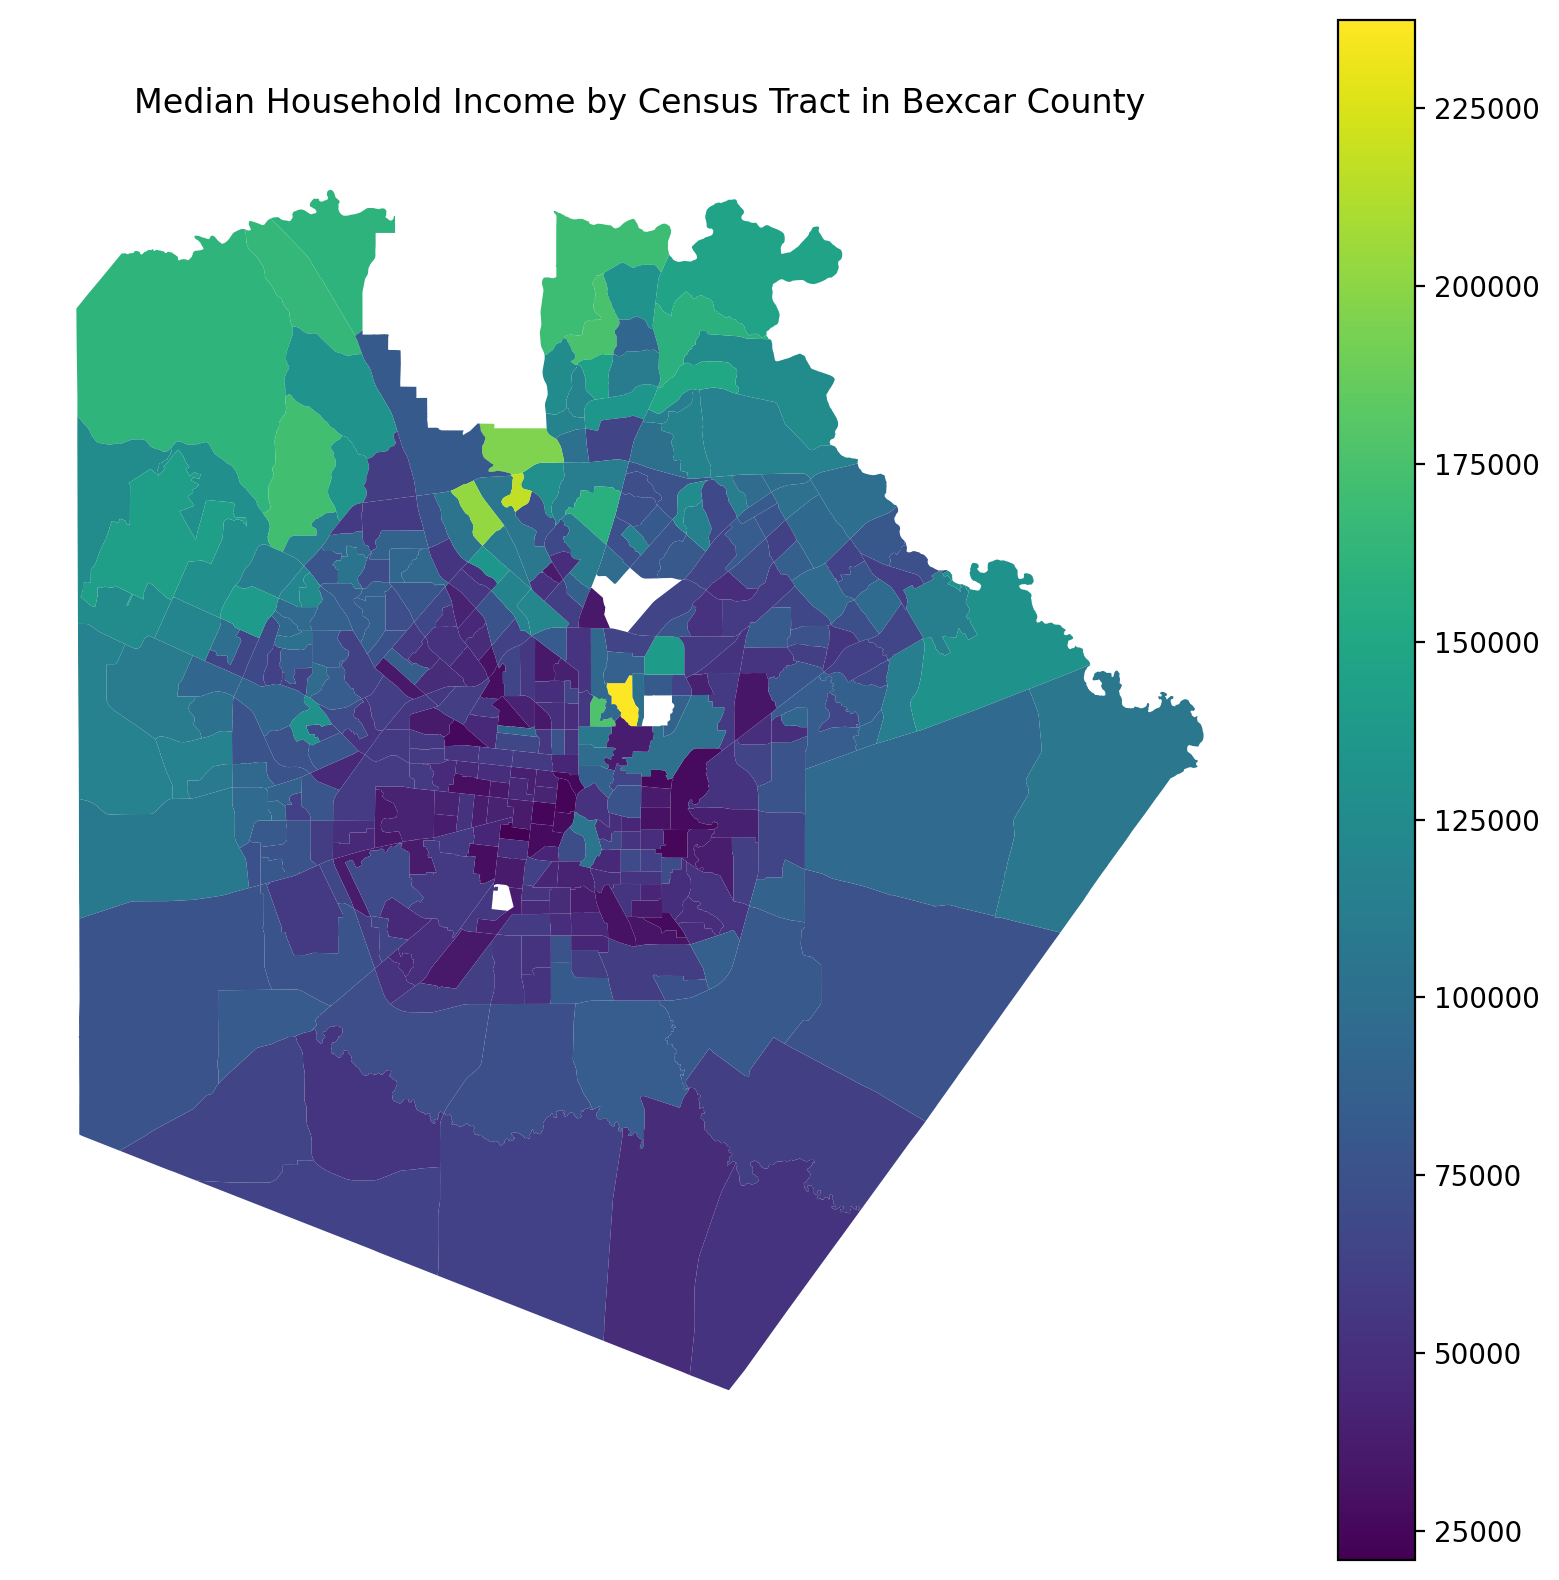

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S1903_C03_001E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Median Household Income by Census Tract in Bexcar County")
plt.axis("off")
plt.show()

# 2. Mobility Map

In [10]:
df = pd.read_csv('vehicle_data.csv')

In [11]:
df

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48029110100,Census Tract 1101; Bexar County; Texas,2614,481,9.8,5.8,15.6,6.3,48.5,9.7,...,0,16.6,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48029110300,Census Tract 1103; Bexar County; Texas,1280,476,0.9,1.3,5.3,4.1,34.2,15.2,...,0,22.2,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48029110500,Census Tract 1105; Bexar County; Texas,1048,353,3.4,5.1,7.8,5.3,57.2,11.9,...,61.3,46.4,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48029110600,Census Tract 1106; Bexar County; Texas,1573,339,0,3.1,5.9,6.5,40.5,10.9,...,0,53.1,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1400000US48029980002,Census Tract 9800.02; Bexar County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
372,1400000US48029980003,Census Tract 9800.03; Bexar County; Texas,583,105,9.4,9.7,32.4,22.7,55.1,15.9,...,0,86.7,(X),(X),(X),(X),(X),(X),(X),(X)
373,1400000US48029980004,Census Tract 9800.04; Bexar County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
374,1400000US48029980005,Census Tract 9800.05; Bexar County; Texas,25,20,0,73.6,0,73.6,48,44.4,...,0,100,(X),(X),(X),(X),(X),(X),(X),(X)


In [14]:
merged = bexcar.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

merged["S0802_C01_094E"] = pd.to_numeric(
    merged["S0802_C01_094E"],
    errors="coerce"
)

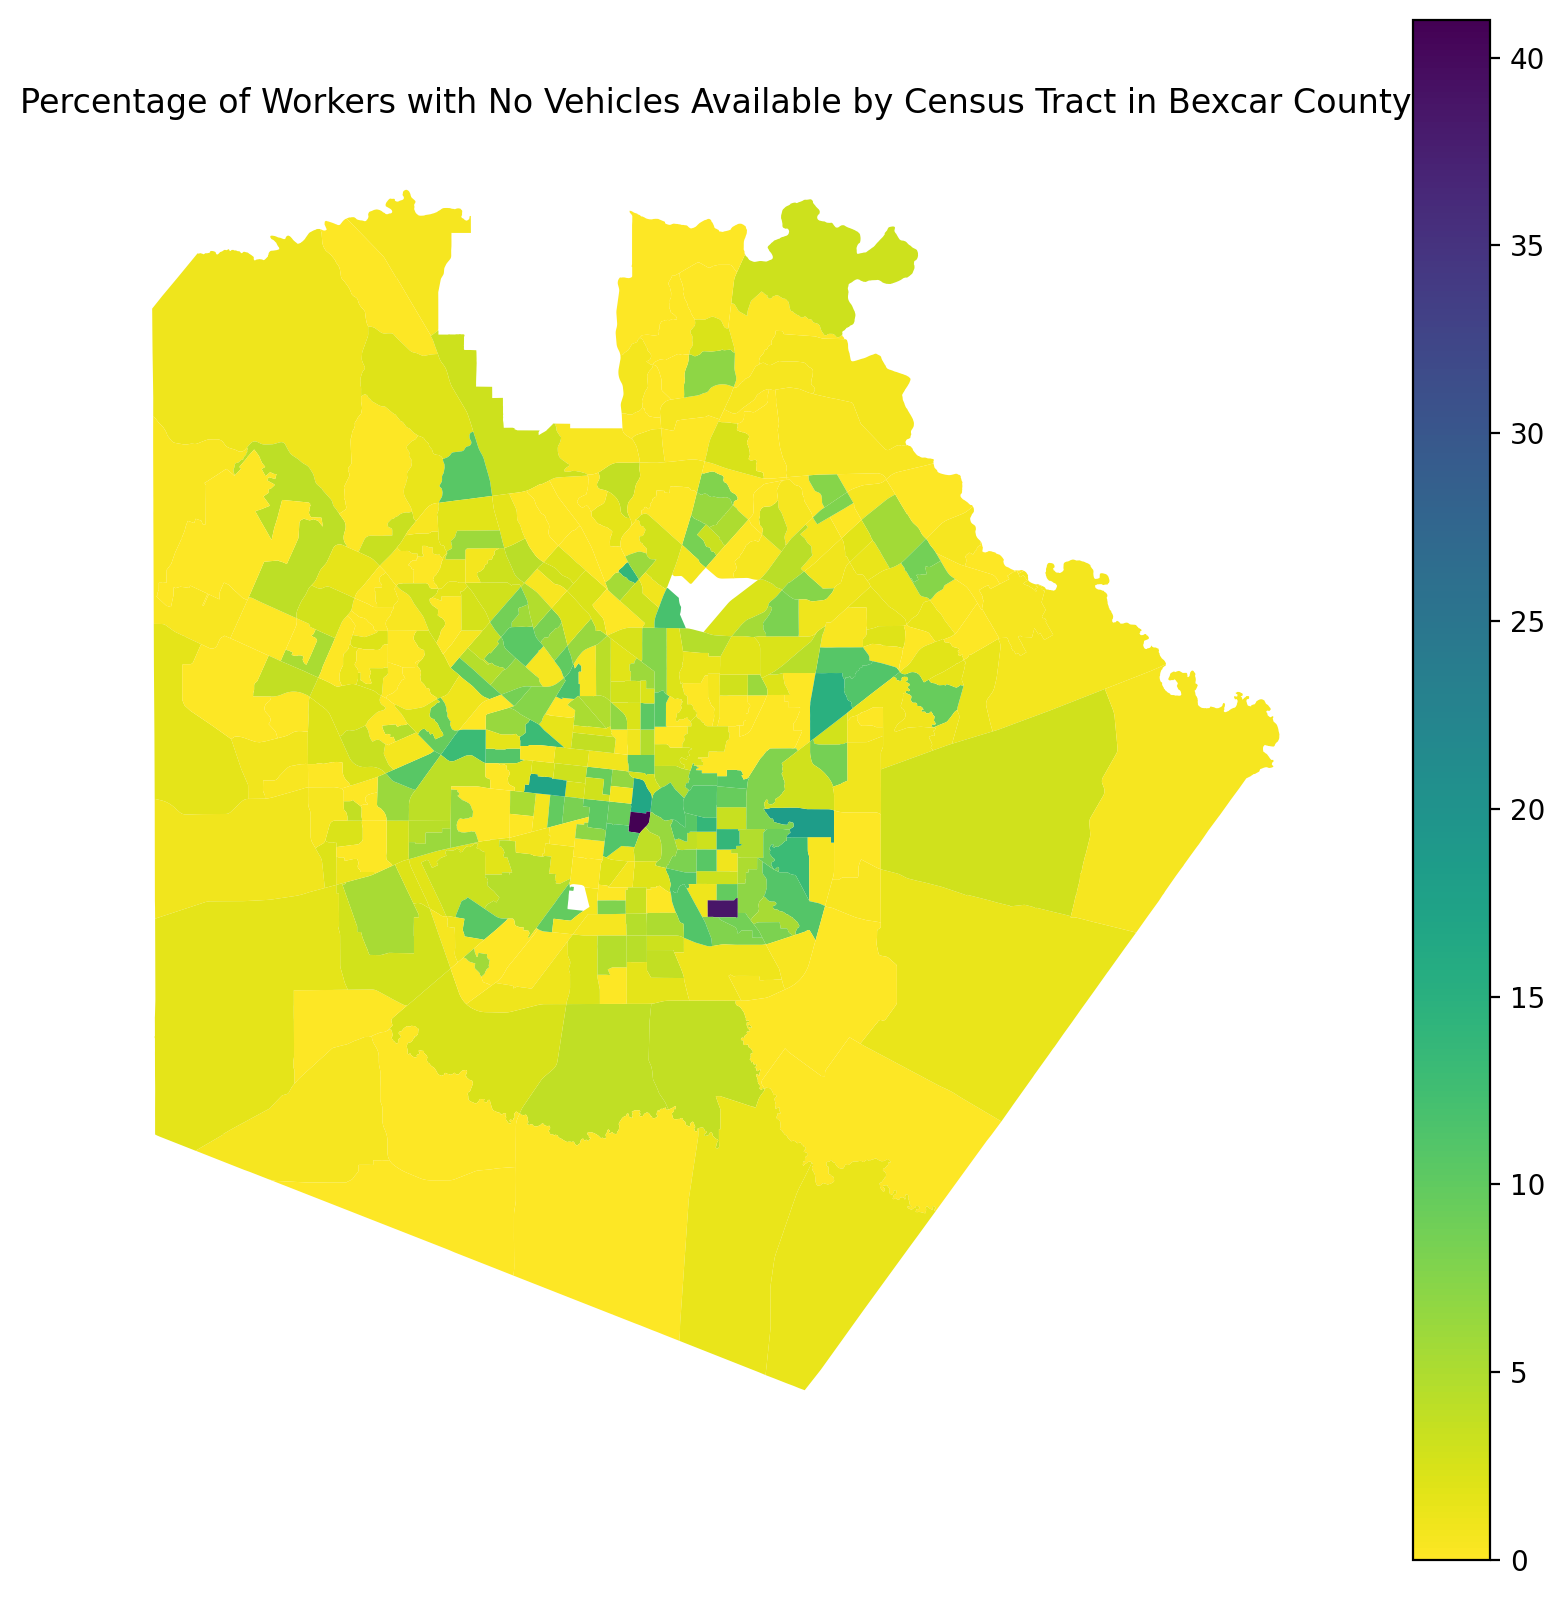

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Bexcar County")
plt.axis("off")
plt.show()

# 3. SNAP Data

In [16]:
df = pd.read_csv('snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48029110100,Census Tract 1101; Bexar County; Texas,2659,341,694,247,1965,299,396,205,...,(X),(X),(X),(X),8.1,8,19.9,19.7,72,21.3
2,1400000US48029110300,Census Tract 1103; Bexar County; Texas,1139,284,390,122,749,260,215,156,...,(X),(X),(X),(X),3.1,3.8,50.1,21.7,46.8,21.7
3,1400000US48029110500,Census Tract 1105; Bexar County; Texas,1115,136,191,84,924,125,101,39,...,(X),(X),(X),(X),16.4,13.1,37.3,23.3,46.2,23.2
4,1400000US48029110600,Census Tract 1106; Bexar County; Texas,1482,249,659,205,823,205,128,74,...,(X),(X),(X),(X),25.7,28.1,8.8,13.1,65.5,30.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1400000US48029980002,Census Tract 9800.02; Bexar County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
372,1400000US48029980003,Census Tract 9800.03; Bexar County; Texas,260,52,25,20,235,46,125,37,...,(X),(X),(X),(X),12.4,9.8,38.8,17.2,48.8,17.8
373,1400000US48029980004,Census Tract 9800.04; Bexar County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
374,1400000US48029980005,Census Tract 9800.05; Bexar County; Texas,19,8,8,9,11,11,19,8,...,(X),(X),(X),(X),21.1,39.9,21.1,30.9,57.9,50


In [17]:
merged = bexcar.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [18]:
merged["S2201_C04_001E"] = pd.to_numeric(
    merged["S2201_C04_001E"],
    errors="coerce"
)

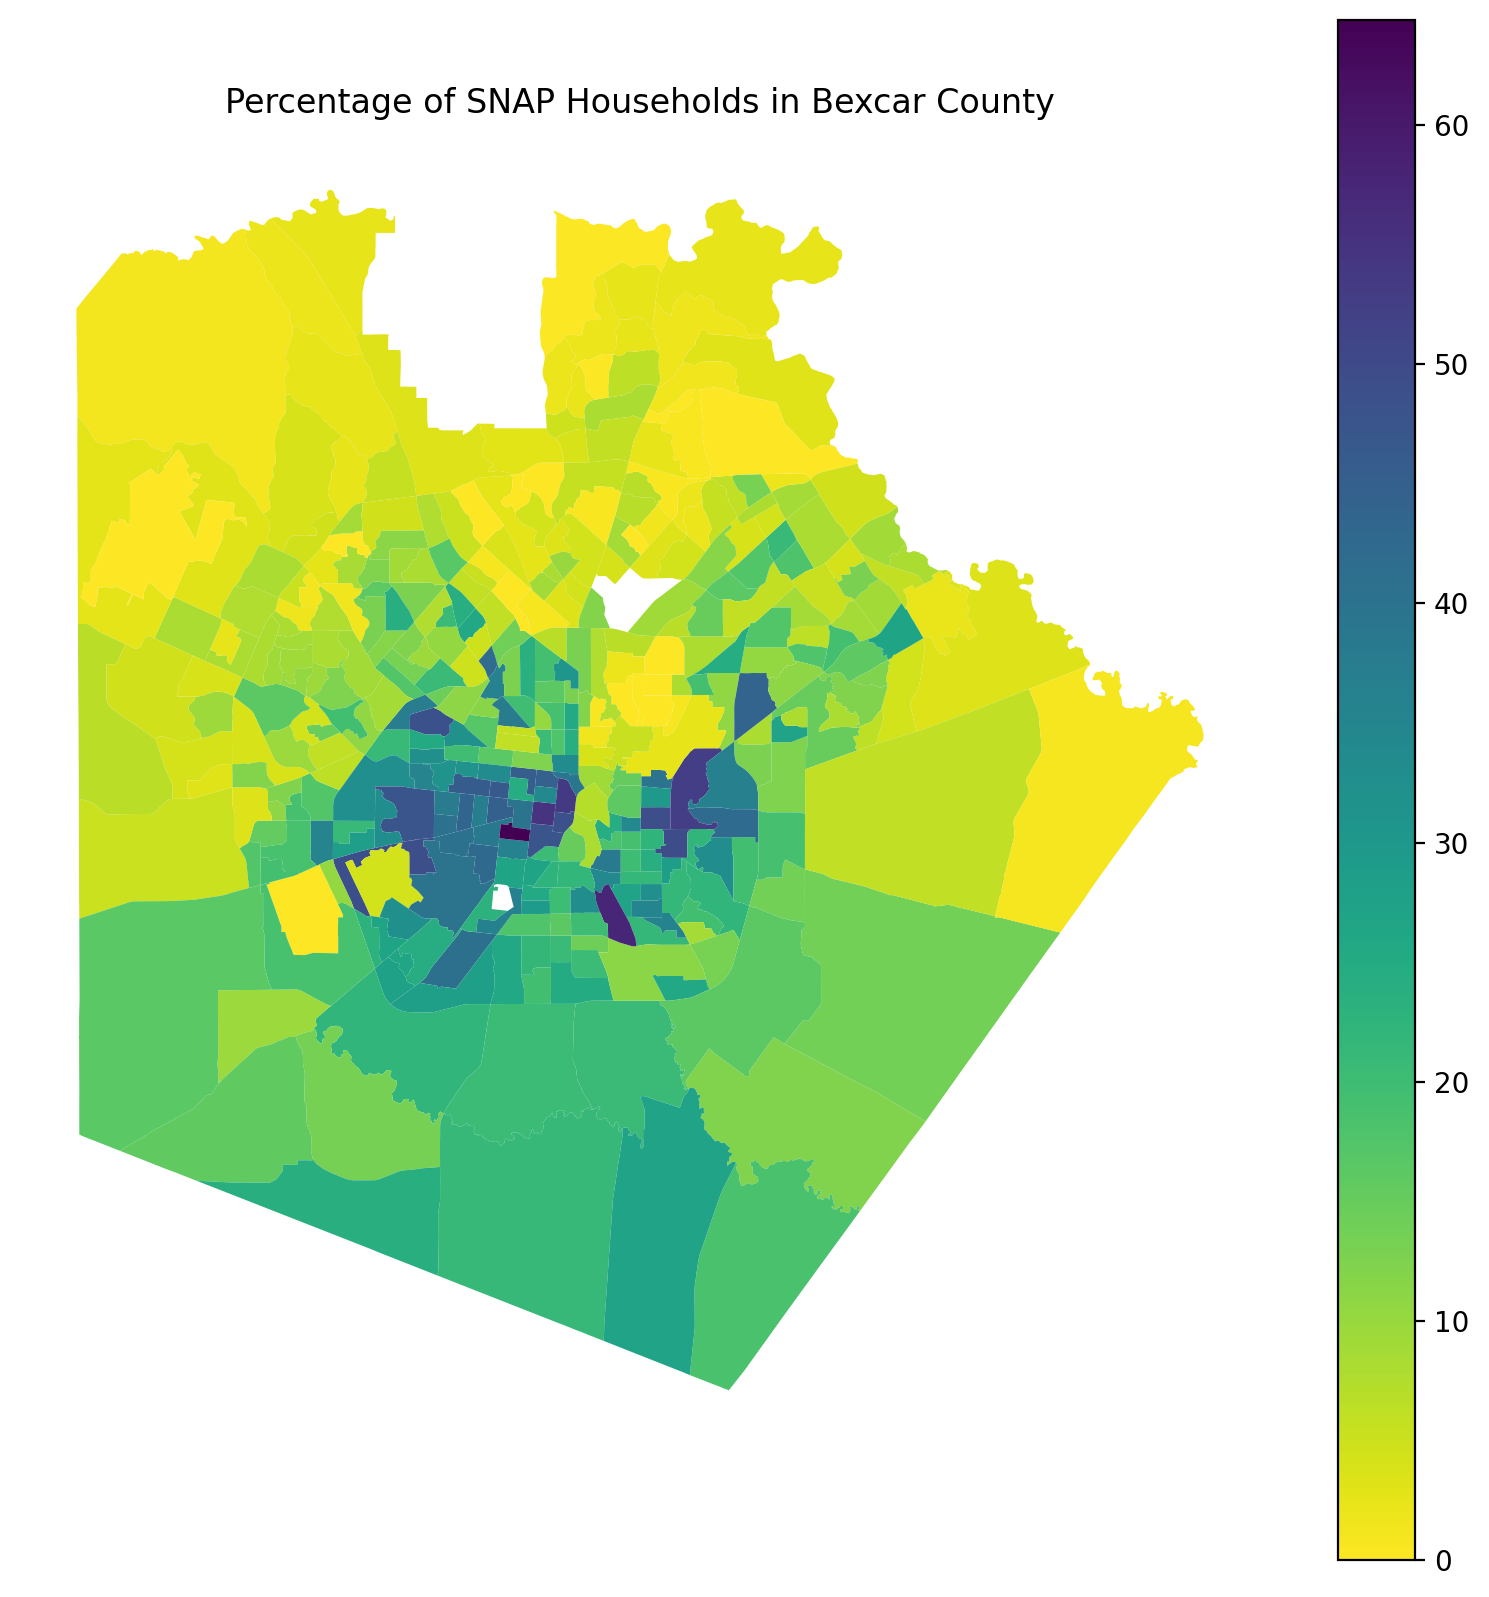

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S2201_C04_001E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households in Bexcar County")
plt.axis("off")
plt.show()